# Genetic Rock Paper Scissors

The original paper shows how, in a _three-way_ prey-predator model, the
unexpected emerging behavior is a sort of _survival of the weakest_, where the
least aggressive species are the ones the most likely will have an higher
population density.

The model does not involve movement but only space conquering by hunting a
nearby cell, which will host the offspring of the predator. The offspring
inherit the invasion probability from the father

- Just by copying it:
  $$ p_\text{new} = p_\text{old} $$
- With a random mutation:
  $$ p_\text{new} = p_\text{old} + \varepsilon $$
  with $\varepsilon \sim \cal{N} (0, 0.01)$

The study shows mainly two cases: 

- Two of the three species invasion probability are held constant, while the
  third is free to evolve through random mutations.
- All three species are free to mutate.

The paper also says how the mutation, in general, drive the population to be
more aggressive on average, that results in:

- A reduced population of the specie free to evolve (first case).
- A dynamical equilibrium, made possible by all three species reaching maximal
  aggression (second case).

## Paper Results Reproduction

The first thing to do is to have a baseline by reproducing the dynamics
described in the paper on a $50 \times 50$ and a maximum of $2000$ epochs
simulation. 

The grid is randomly initialized by sampling one of the three species for each
cell with equal probability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import mesa

from grps import RPSModel
import grps.evolution_policies as evo


def plot_densities(data: pd.DataFrame) -> None:
    plt.figure(dpi=150)
    plt.title("Population Density")
    plt.plot(data["R_density"], c="red", label="rock")
    plt.plot(data["P_density"], c="blue", label="paper")
    plt.plot(data["S_density"], c="green", label="scissors")
    plt.xlabel("Epoch")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_average_invasions(data: pd.DataFrame) -> None:
    # Average invasion rate
    plt.figure(dpi=150)
    plt.title("Average Invasion Rate")
    plt.plot(data["R_invasion"], c="red", label="rock")
    plt.plot(data["P_invasion"], c="blue", label="paper")
    plt.plot(data["S_invasion"], c="green", label="scissors")
    plt.axhline(1.0, ls="--", c="gray", label="max invasion")
    plt.xlabel("Epoch")
    plt.ylabel("Mean invasion probability")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_average_age(data: pd.DataFrame) -> None:
    # Average age
    plt.figure(dpi=150)
    plt.title("Average Age")
    plt.plot(data["R_age"], c="red", label="rock")
    plt.plot(data["P_age"], c="blue", label="paper")
    plt.plot(data["S_age"], c="green", label="scissors")
    plt.xlabel("Epoch")
    plt.ylabel("Mean age (epochs)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def visualize_grid(model: RPSModel) -> None:
    # Final grid state
    color_map = {"rock": 0, "paper": 1, "scissors": 2}
    grid_arr = np.full((model.grid.width, model.grid.height), -1)
    for agent in model.agents:
        x, y = agent.cell.coordinate
        grid_arr[x, y] = color_map[agent.specie]

    plt.figure(dpi=150)
    plt.title("Final Grid State")
    cmap = ListedColormap(["red", "blue", "green"])
    im = plt.imshow(grid_arr.T, cmap=cmap, interpolation="nearest", origin="lower")
    cbar = plt.colorbar(im, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(["rock", "paper", "scissors"])
    plt.tight_layout()
    plt.show()


In [2]:
# config parameters
dim = 75  # grid dimension
epochs = 500  # simulation max epochs
sigma = 0.05  # standard deviation for mutation offset

### Inheritance

The first case of study assigns at each specie individual an invasion
probability, which will inhertied by their offsprings after the reproduction.

Here the goal is just to reproduce the main result of the paper (survival of the
weakest), by assigning a lower invasion probability to one of the three species
and see if in the end it has the highest population density.

In [3]:
policies = {
    "rock": evo.Inheritance(),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.1, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [02:21<00:00,  3.53it/s]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.1,0.5,0.5,0.000000,0.000000,0.000000
1,1683,1829,2113,0.1,0.5,0.5,1.000000,1.000000,1.000000
2,1508,1758,2359,0.1,0.5,0.5,1.964191,1.879408,1.870284
3,1397,1590,2638,0.1,0.5,0.5,2.874732,2.679874,2.625095
4,1318,1400,2907,0.1,0.5,0.5,3.710167,3.393571,3.313725
...,...,...,...,...,...,...,...,...,...
495,2777,312,2536,0.1,0.5,0.5,34.598848,7.413462,49.596215
496,2796,314,2515,0.1,0.5,0.5,34.624464,7.165605,49.727634
497,2821,311,2493,0.1,0.5,0.5,34.792627,7.170418,49.739270
498,2855,301,2469,0.1,0.5,0.5,34.858494,7.289037,49.791819


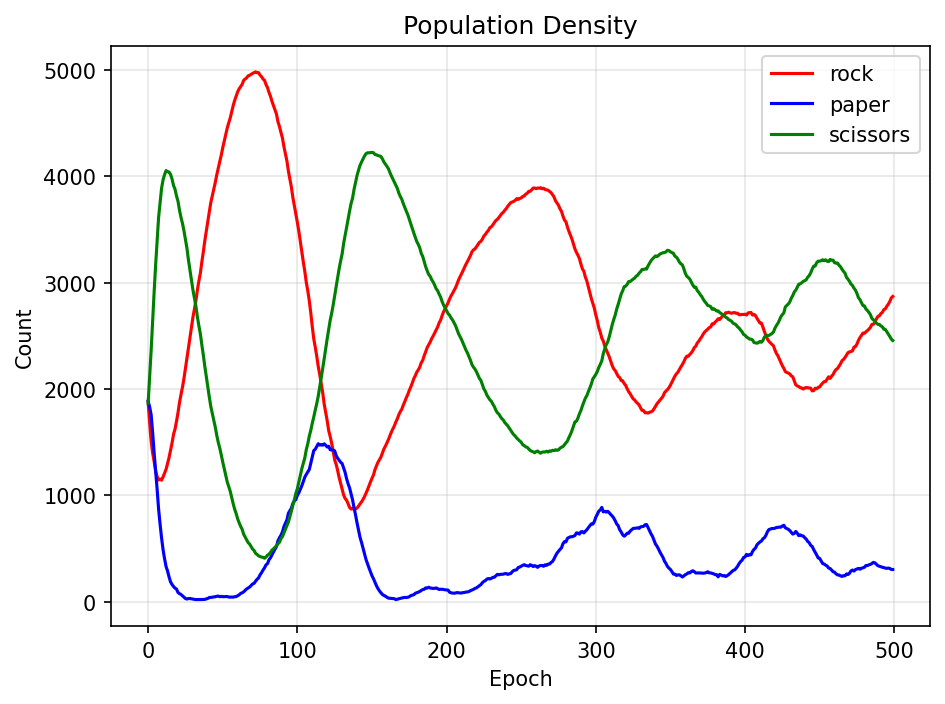

In [4]:
plot_densities(data)

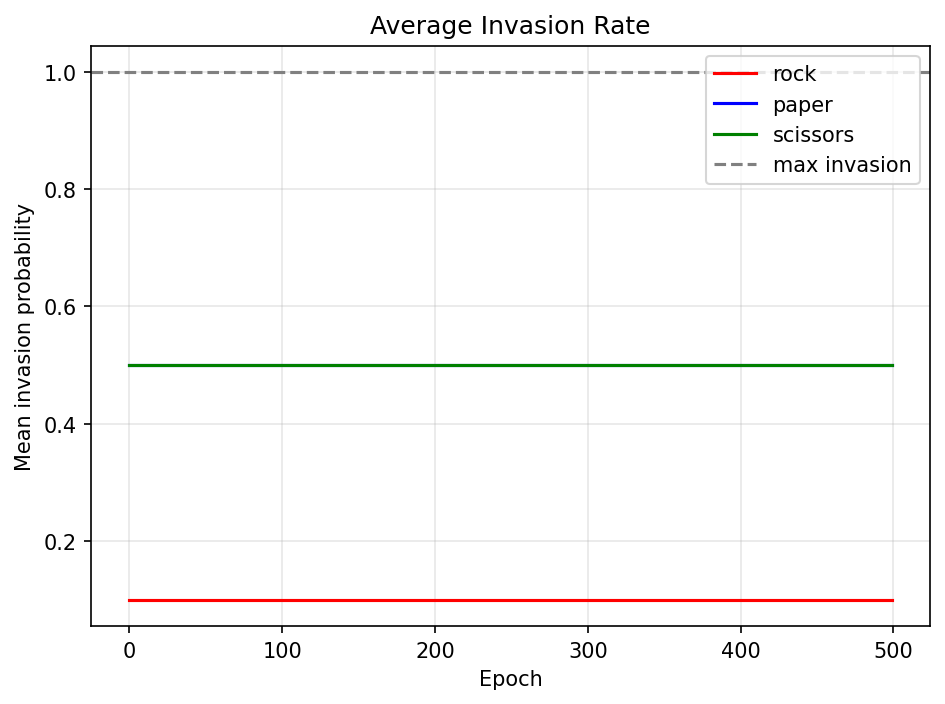

In [5]:
plot_average_invasions(data)

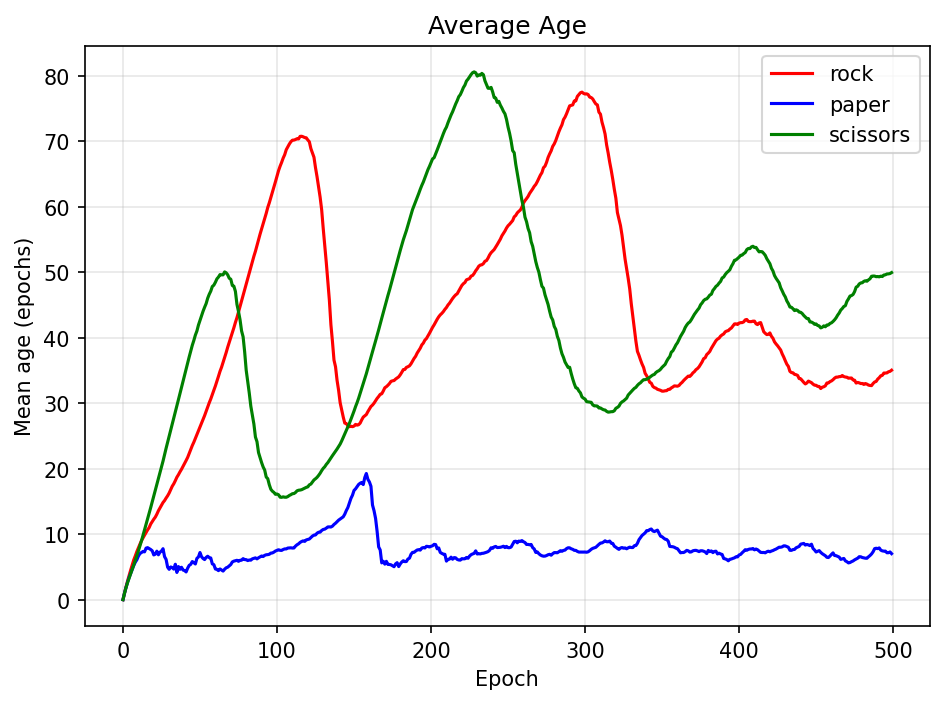

In [6]:
plot_average_age(data)

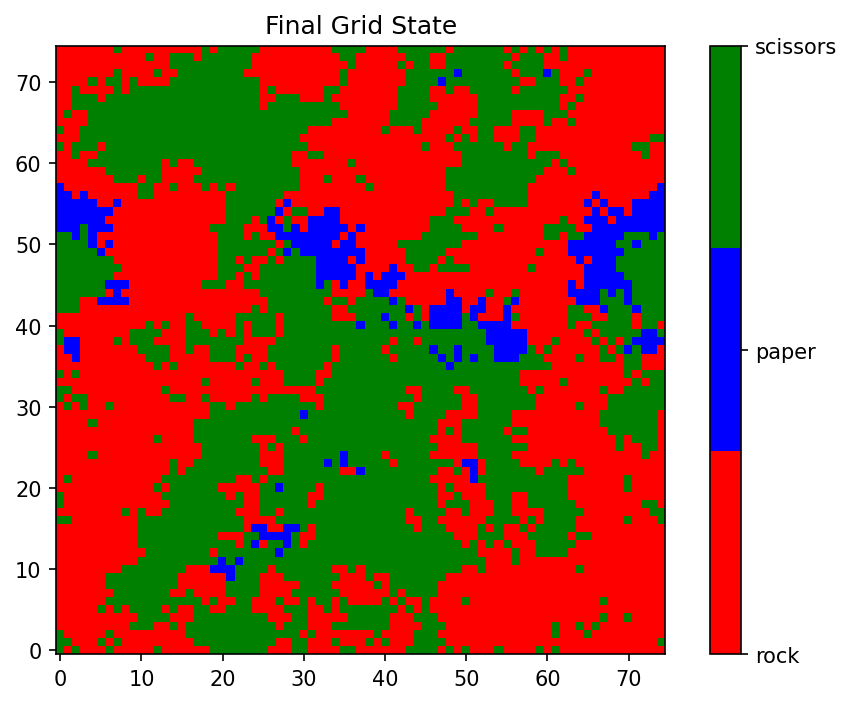

In [7]:
visualize_grid(model)

### Stochastic Mutation of 1 Specie

The other main result shown was obtained by keeping two species invasion
probabilites fixed, while the third can mutate.

Here the end result can vary, depending on initial conditions and initial
invasion probabilities assigned to each specie.

In the following simulations are shown two main scenarios:

- Every specie starts with an initial invasion rate of $0.5$.
- The evolvable specie starts with a low invasion rate of $0.1$.

The two models might converge to the same result, since in the paper is said
that the mutated specie tends to be more aggressive in the end.

In [8]:
policies = {
    "rock": evo.Stochastic(sigma=sigma),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.5, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [02:26<00:00,  3.41it/s]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.500000,0.5,0.5,0.000000,0.000000,0.000000
1,1891,1891,1843,0.499681,0.5,0.5,1.000000,1.000000,1.000000
2,1908,1895,1822,0.499863,0.5,0.5,1.855346,1.857520,1.857300
3,1897,1894,1834,0.499889,0.5,0.5,2.607802,2.594509,2.582334
4,1890,1896,1839,0.499059,0.5,0.5,3.250794,3.213608,3.213703
...,...,...,...,...,...,...,...,...,...
495,1084,2832,1709,0.836667,0.5,0.5,6.083026,13.250706,6.928613
496,1109,2783,1733,0.844170,0.5,0.5,5.787196,13.471434,6.993076
497,1163,2738,1724,0.846441,0.5,0.5,5.692175,13.661066,7.053364
498,1206,2667,1752,0.845443,0.5,0.5,5.585406,13.860142,7.091895


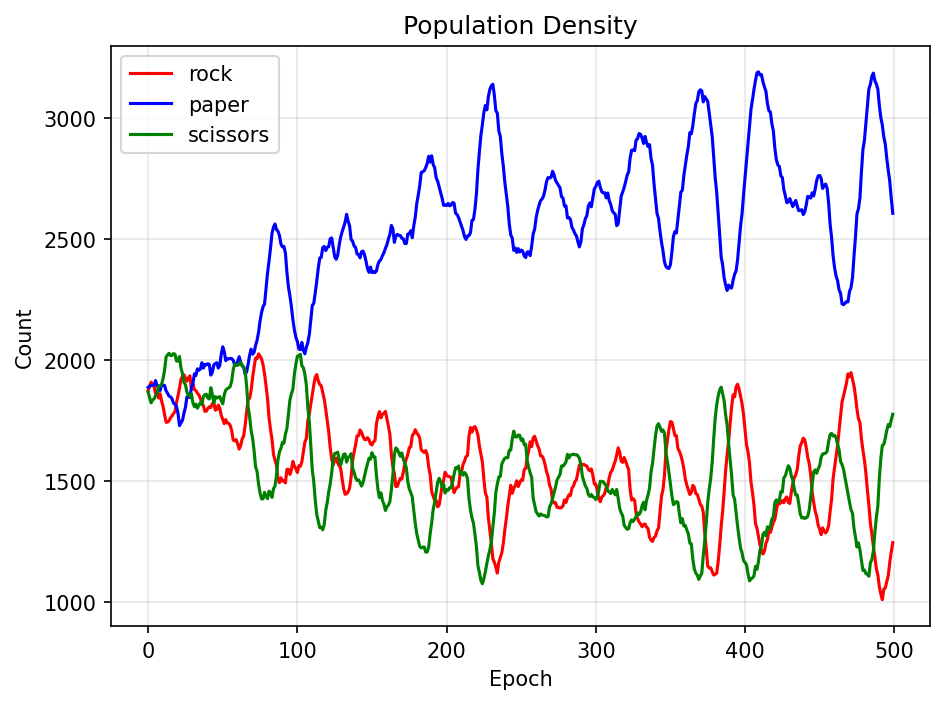

In [9]:
plot_densities(data)

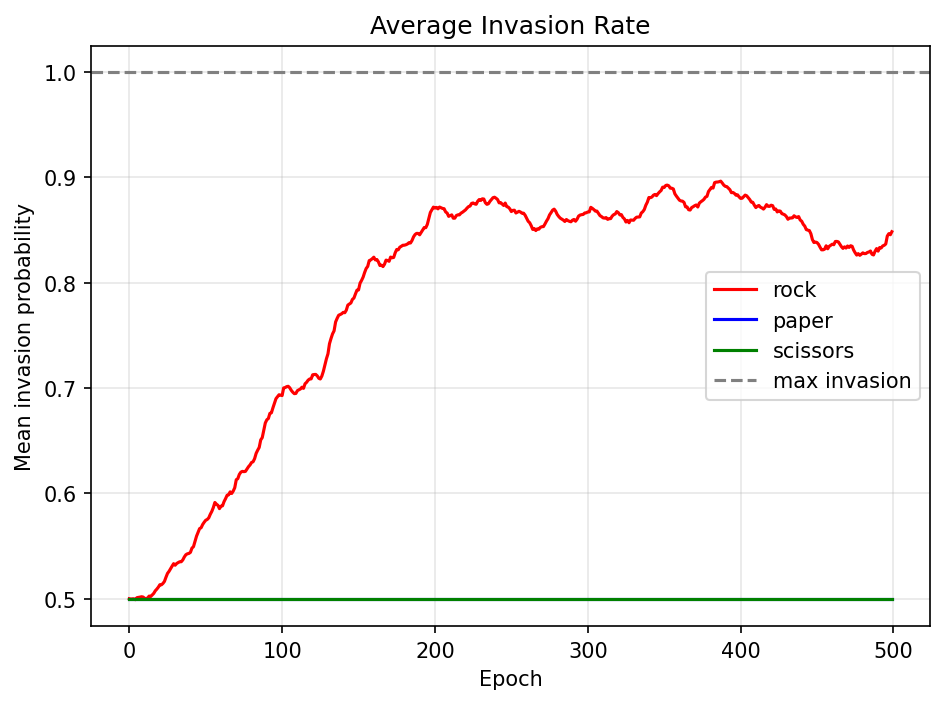

In [10]:
plot_average_invasions(data)

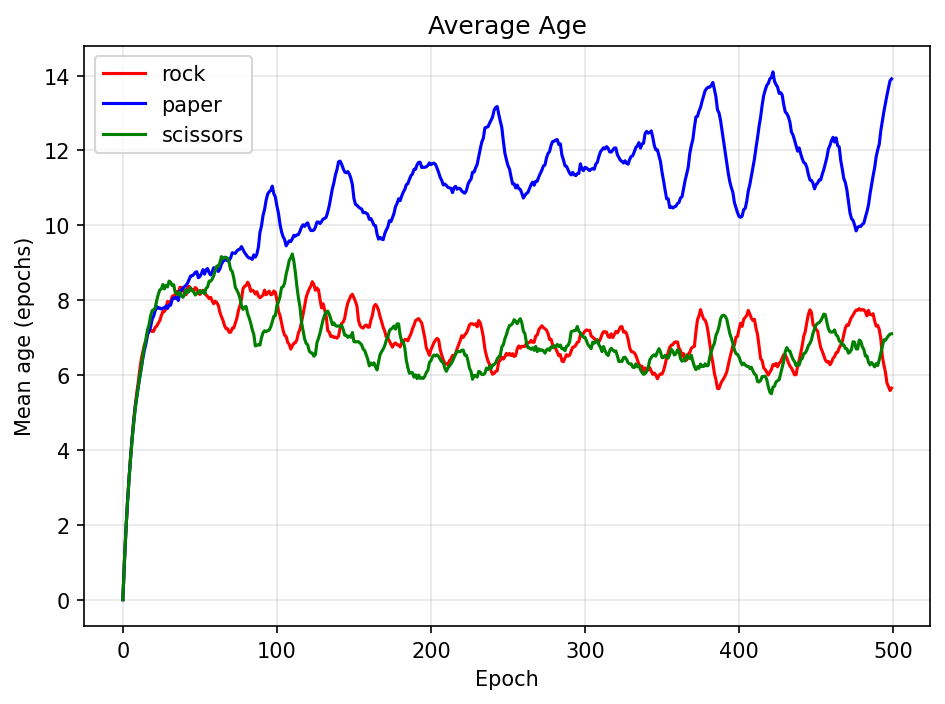

In [11]:
plot_average_age(data)

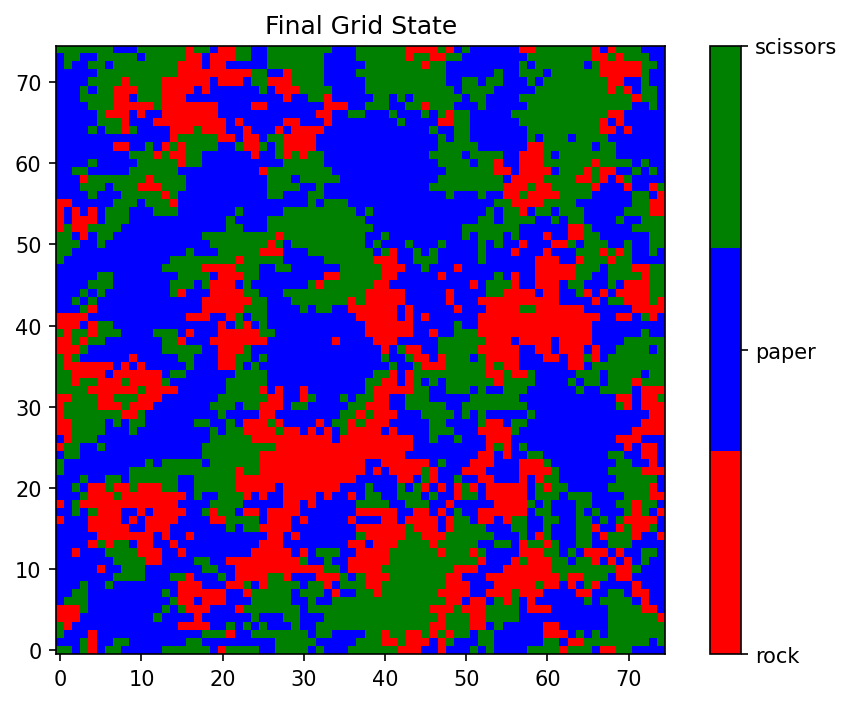

In [12]:
visualize_grid(model)

Just looking at the mutable specie (rock) the final result is not very
surprising, since it shows an increasing invasion probability and does not end
up being the most numerous specie.

In [13]:
policies = {
    "rock": evo.Stochastic(sigma=sigma),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.1, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [02:25<00:00,  3.44it/s]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.100000,0.5,0.5,0.000000,0.000000,0.000000
1,1683,1822,2120,0.100104,0.5,0.5,1.000000,1.000000,1.000000
2,1523,1735,2367,0.100199,0.5,0.5,1.960604,1.882997,1.869455
3,1420,1561,2644,0.099827,0.5,0.5,2.874648,2.695067,2.627837
4,1351,1357,2917,0.100219,0.5,0.5,3.705403,3.409727,3.312307
...,...,...,...,...,...,...,...,...,...
495,1742,2458,1425,0.869554,0.5,0.5,7.374856,10.707079,6.606316
496,1745,2438,1442,0.868204,0.5,0.5,7.502006,10.672683,6.569348
497,1739,2457,1429,0.863416,0.5,0.5,7.539965,10.614978,6.753674
498,1721,2480,1424,0.862073,0.5,0.5,7.596165,10.570161,6.876404


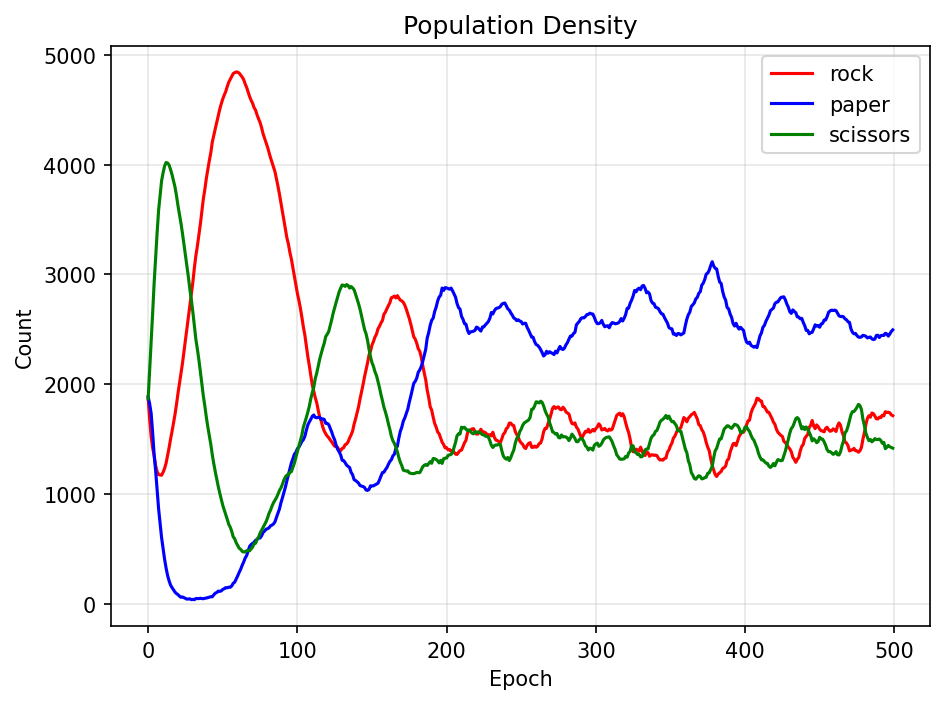

In [14]:
plot_densities(data)

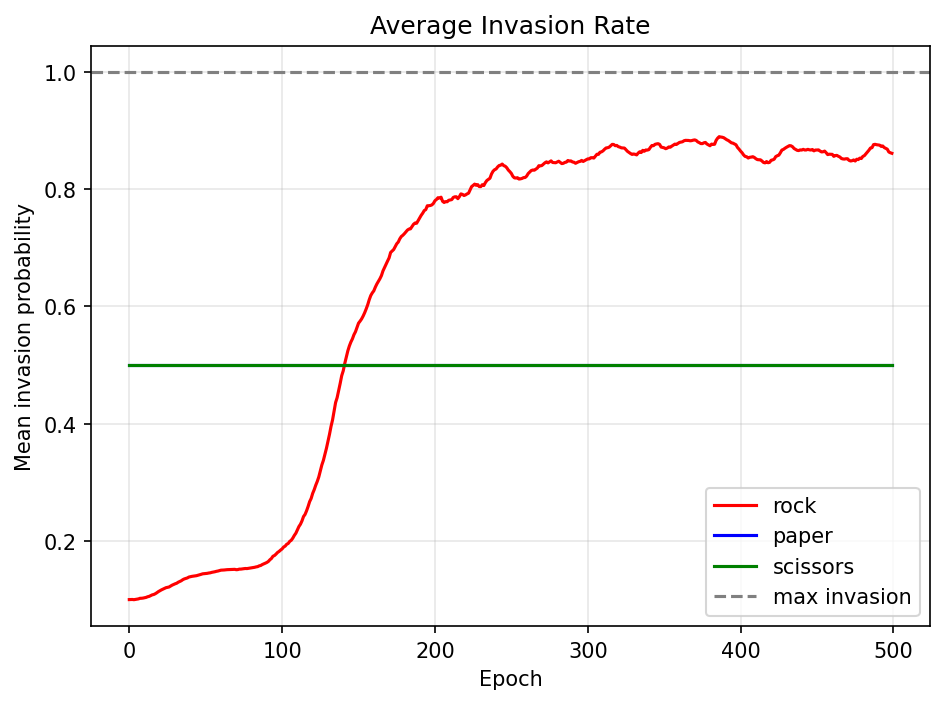

In [15]:
plot_average_invasions(data)

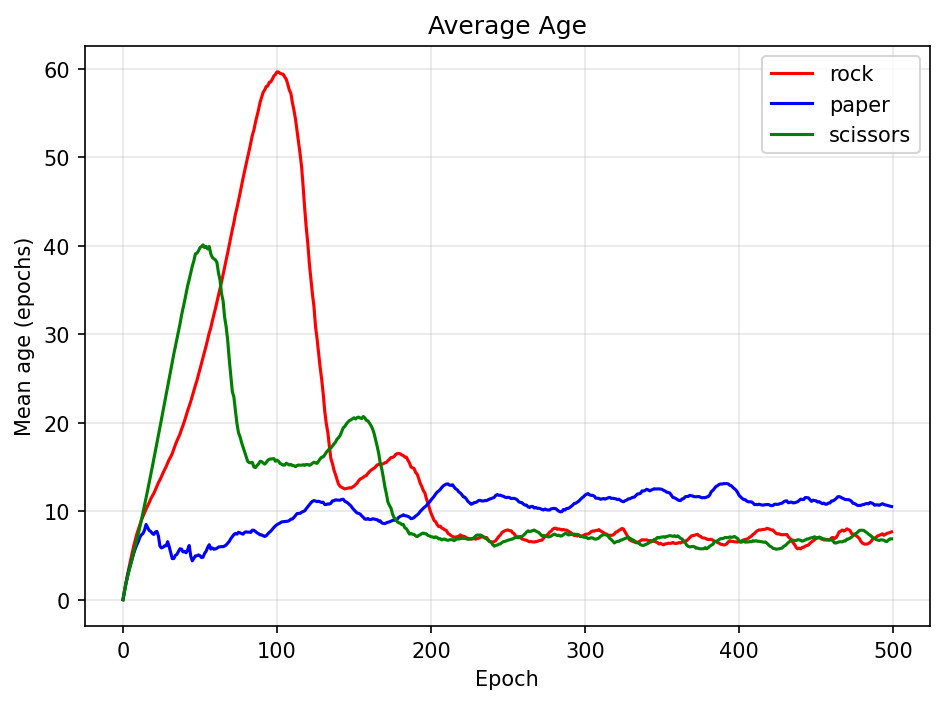

In [16]:
plot_average_age(data)

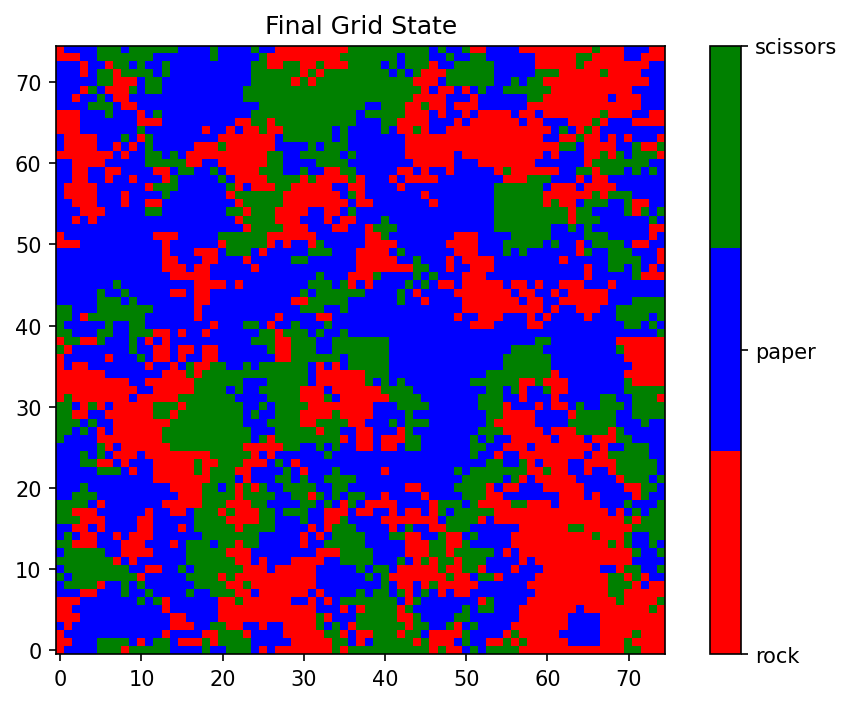

In [17]:
visualize_grid(model)

Also for this setup nothing really surprising: since rock starts with a low
invasion probability, its population grows fast but more aggressive over time.

After few iterations the invasion rate is already back to $0.5$, causing the
same dynamics as the previous simulation. 

### Stochastic Mutation of 3 Species

Another experiment consists in let all three species evolve via random
mutations, in the paper is mentioned how an equilibrium through maximal
aggression should be reached. 

It follows just a simulation in which every specie starts with an invasion
probability of $0.1$.

In [18]:
policies = {
    "rock": evo.Stochastic(sigma=sigma),
    "paper": evo.Stochastic(sigma=sigma),
    "scissors": evo.Stochastic(sigma=sigma),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.1, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [02:28<00:00,  3.37it/s]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.100000,0.500000,0.500000,0.000000,0.000000,0.000000
1,1666,1836,2123,0.100255,0.498983,0.500946,1.000000,1.000000,1.000000
2,1513,1742,2370,0.100348,0.498920,0.501342,1.960344,1.885189,1.868776
3,1410,1587,2628,0.100379,0.499398,0.501471,2.860284,2.694392,2.632801
4,1335,1393,2897,0.100843,0.499362,0.501407,3.705618,3.422828,3.322402
...,...,...,...,...,...,...,...,...,...
495,1834,1723,2068,0.872579,0.890371,0.871277,5.200109,5.185142,5.983075
496,1843,1752,2030,0.873442,0.890464,0.874335,5.226262,5.156393,6.148276
497,1842,1810,1973,0.872826,0.890949,0.872275,5.203583,5.095580,6.306640
498,1849,1843,1933,0.874918,0.892038,0.872779,5.199027,5.066739,6.260735


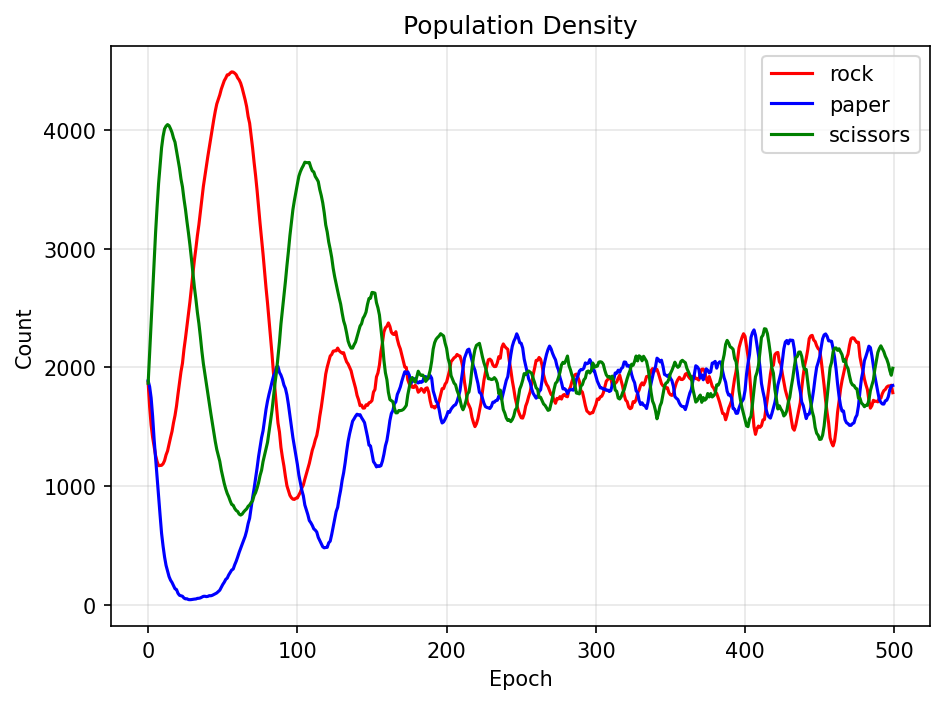

In [19]:
plot_densities(data)

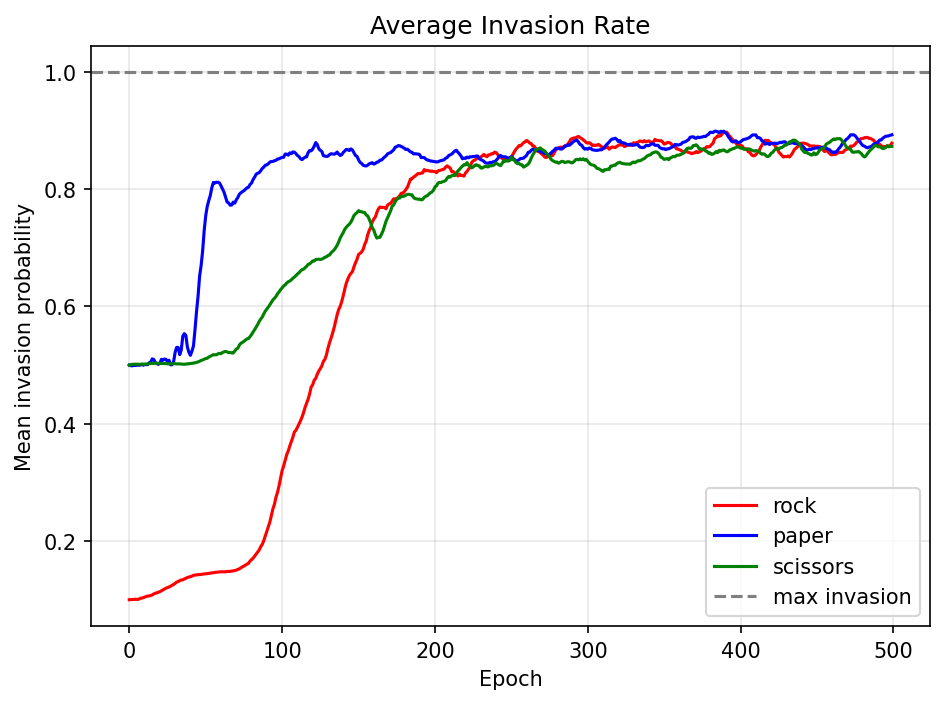

In [20]:
plot_average_invasions(data)

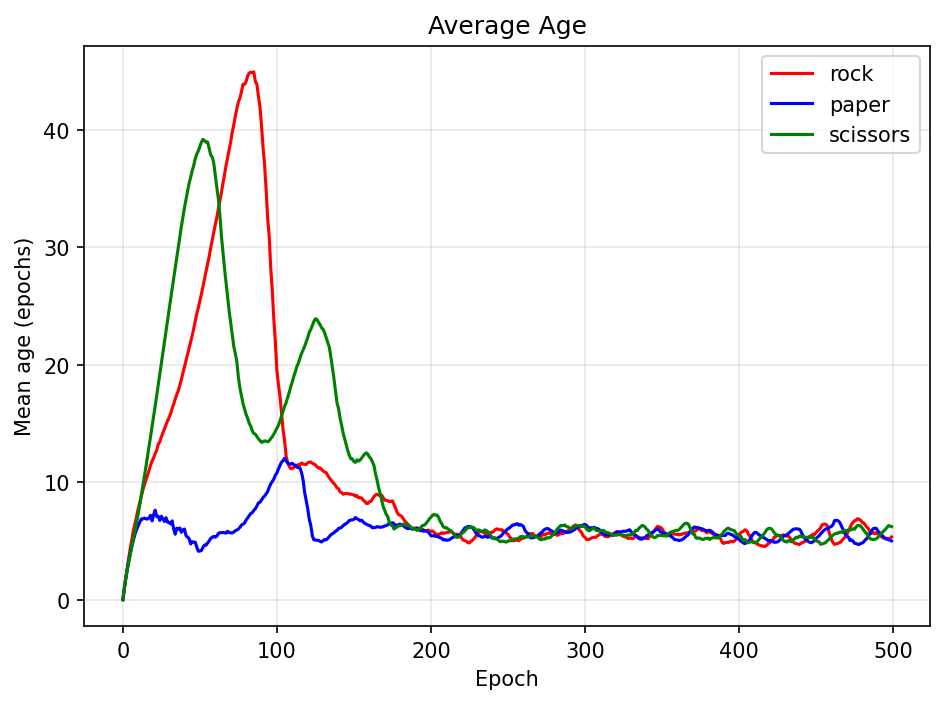

In [21]:
plot_average_age(data)

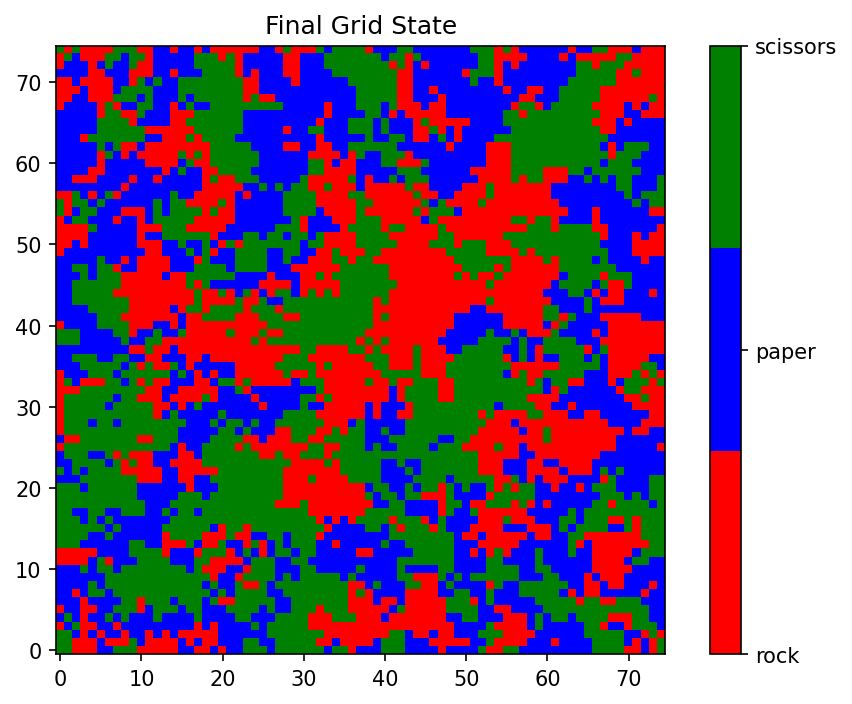

In [22]:
visualize_grid(model)

## Proposed Extension

The proposed extension adds a more structured dynamics of evolution and
reproduction. It is based on the assumption that _older_ individuals may have a
better strategy to survive.

In this perspective the proposed reproduction method is extended by **mating**
with _near_ and _fit_ individuals, trying to obtain a long-lived population.

In [23]:
radius = 10
policies = {
    "rock": evo.Genetic(sigma=sigma, radius=radius),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.5, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [08:26<00:00,  1.01s/it]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.500000,0.5,0.5,0.000000,0.000000,0.000000
1,1898,1858,1869,0.498840,0.5,0.5,1.000000,1.000000,1.000000
2,1902,1882,1841,0.498709,0.5,0.5,1.855415,1.853879,1.863118
3,1920,1856,1849,0.498502,0.5,0.5,2.599479,2.610453,2.597620
4,1932,1858,1835,0.499149,0.5,0.5,3.234990,3.237352,3.228883
...,...,...,...,...,...,...,...,...,...
495,1895,1904,1826,0.609320,0.5,0.5,6.860158,9.779412,8.554217
496,1905,1947,1773,0.608152,0.5,0.5,7.063517,9.657935,8.775522
497,1910,1974,1741,0.607851,0.5,0.5,7.115707,9.635765,8.797817
498,1923,1983,1719,0.607595,0.5,0.5,7.290172,9.696924,8.835951


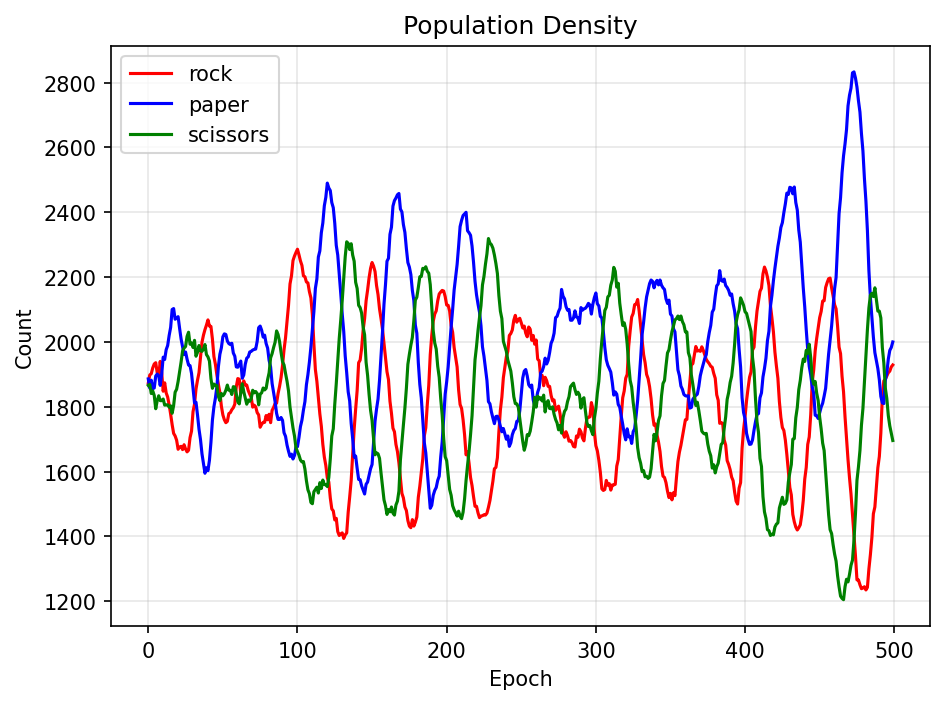

In [24]:
plot_densities(data)

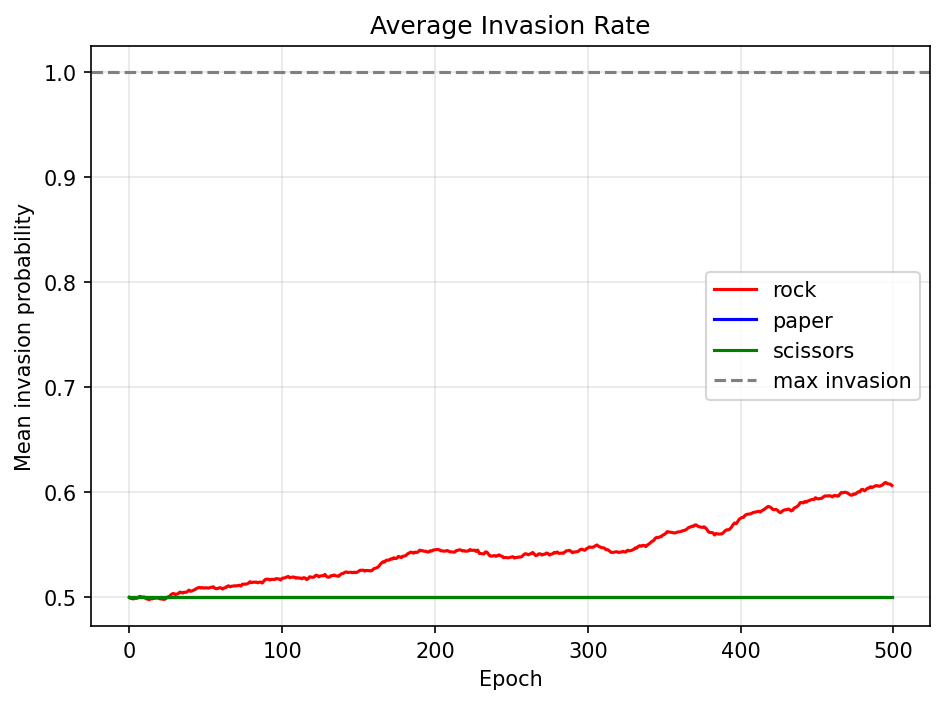

In [25]:
plot_average_invasions(data)

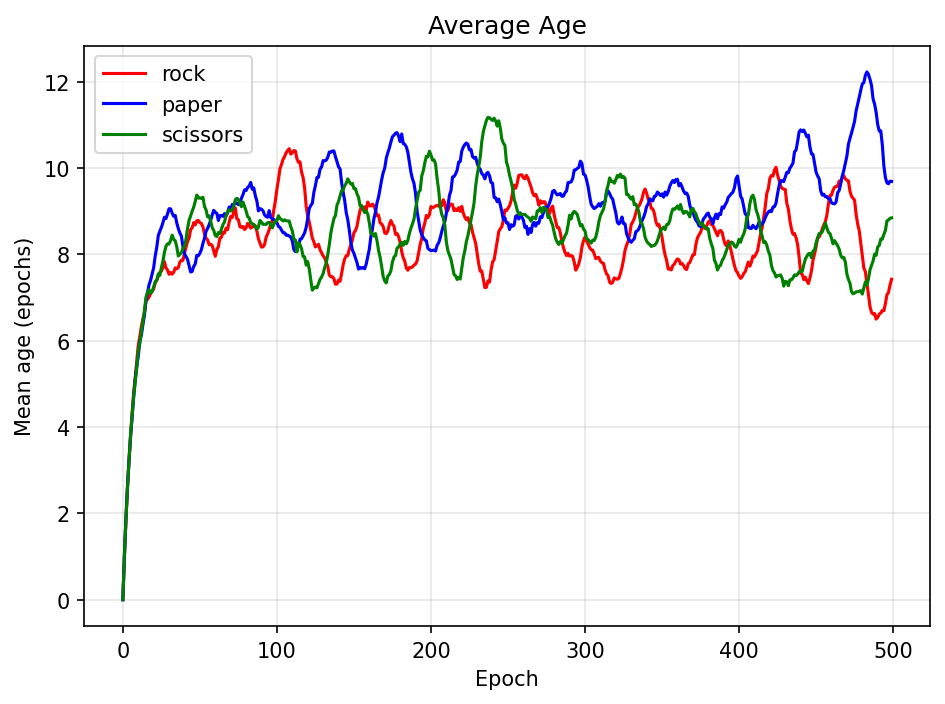

In [26]:
plot_average_age(data)

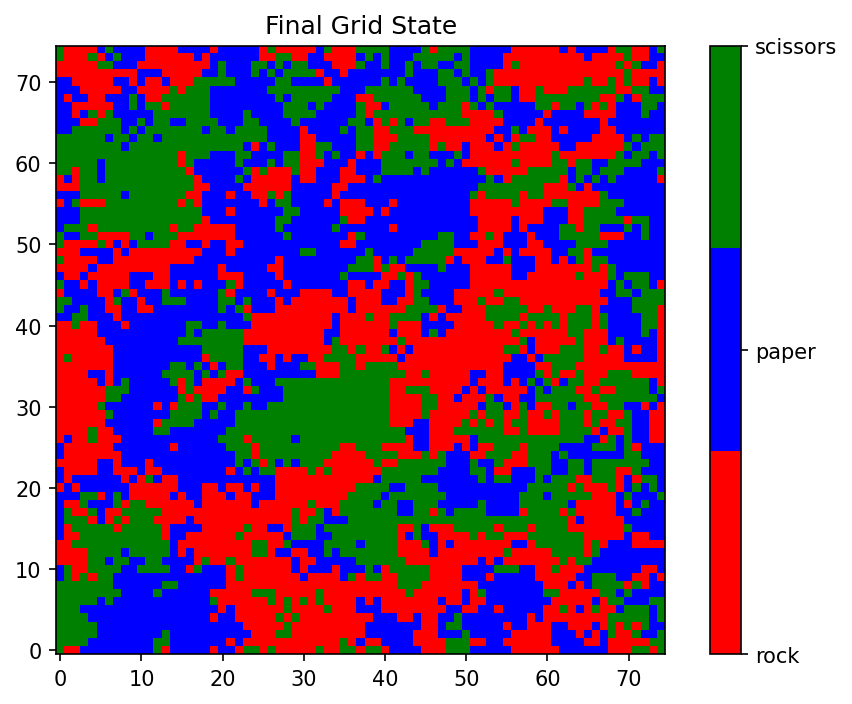

In [27]:
visualize_grid(model)

In [28]:
policies = {
    "rock": evo.Genetic(sigma=sigma, radius=radius),
    "paper": evo.Genetic(sigma=sigma, radius=radius),
    "scissors": evo.Genetic(sigma=sigma, radius=radius),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.5, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [21:11<00:00,  2.54s/it]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000
1,1902,1879,1844,0.501043,0.499141,0.500866,1.000000,1.000000,1.000000
2,1903,1889,1833,0.501989,0.498868,0.500088,1.858644,1.854420,1.858156
3,1895,1872,1858,0.502428,0.499315,0.501126,2.615303,2.597756,2.590420
4,1889,1893,1843,0.502040,0.499486,0.501186,3.250397,3.223983,3.234400
...,...,...,...,...,...,...,...,...,...
495,2019,1861,1745,0.582452,0.582631,0.591261,7.822684,7.742074,8.020630
496,2020,1853,1752,0.582693,0.584144,0.591821,7.913366,7.740961,7.703196
497,2019,1842,1764,0.583150,0.584917,0.593704,7.976226,7.855592,7.575964
498,1992,1871,1762,0.584487,0.585182,0.594118,8.131024,7.889364,7.548241


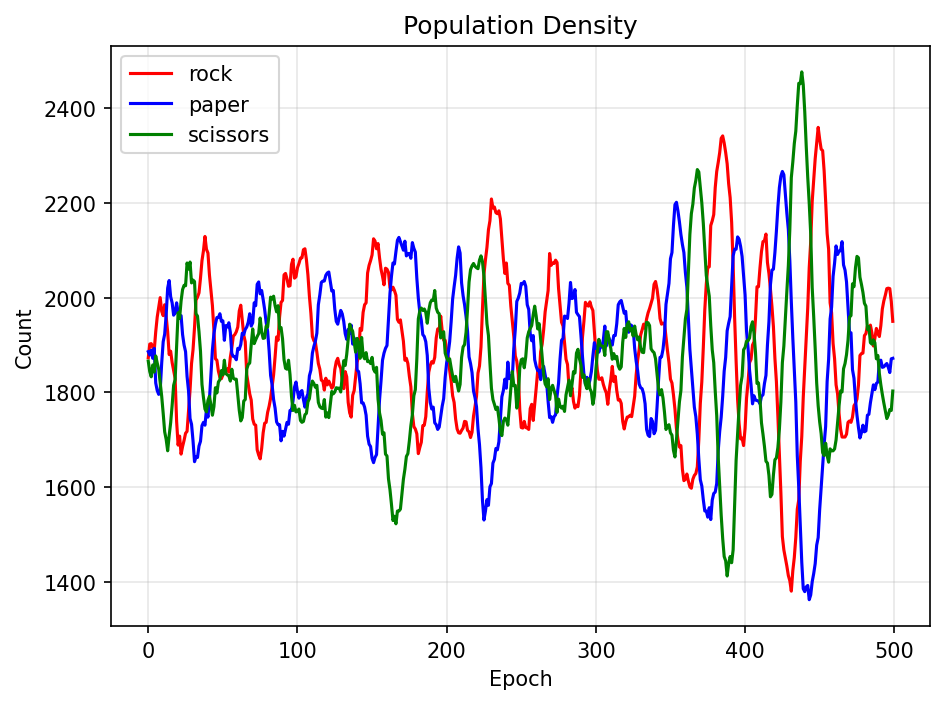

In [29]:
plot_densities(data)

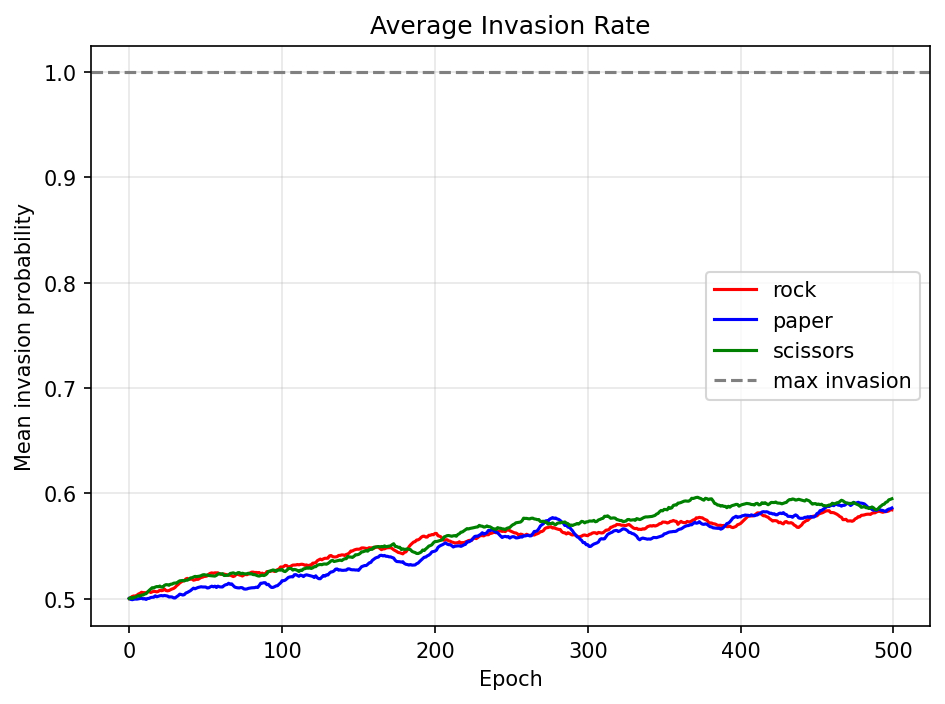

In [30]:
plot_average_invasions(data)

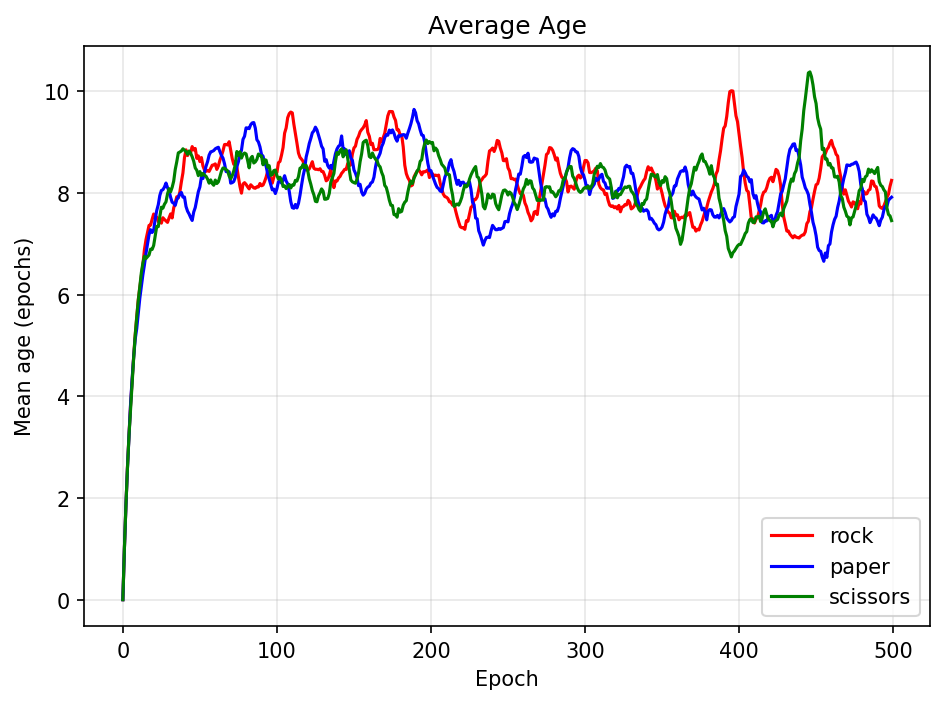

In [31]:
plot_average_age(data)

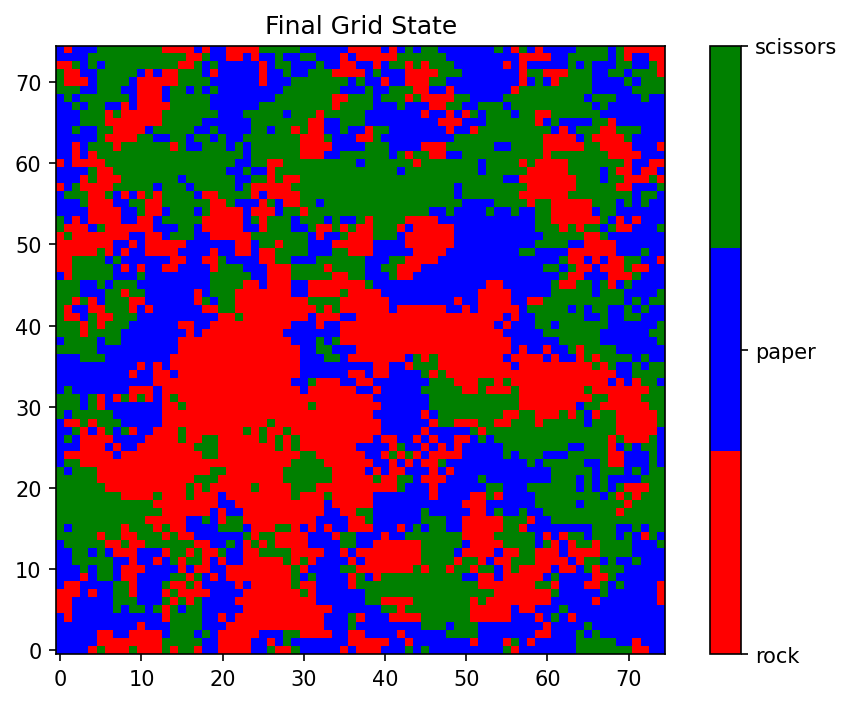

In [32]:
visualize_grid(model)

In [33]:
radius = 20
policies = {
    "rock": evo.Genetic(sigma=sigma, radius=radius),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.5, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [09:07<00:00,  1.10s/it]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.500000,0.5,0.5,0.000000,0.000000,0.000000
1,1899,1857,1869,0.498798,0.5,0.5,1.000000,1.000000,1.000000
2,1903,1881,1841,0.498811,0.5,0.5,1.855491,1.853801,1.863118
3,1907,1850,1868,0.498288,0.5,0.5,2.606712,2.607568,2.592077
4,1916,1851,1858,0.498563,0.5,0.5,3.248434,3.233387,3.231970
...,...,...,...,...,...,...,...,...,...
495,1785,2285,1555,0.631585,0.5,0.5,7.927731,9.913348,7.980064
496,1796,2298,1531,0.632126,0.5,0.5,7.786748,9.920801,7.856956
497,1782,2292,1551,0.632009,0.5,0.5,7.812009,9.937609,7.599613
498,1791,2277,1557,0.630803,0.5,0.5,7.938023,10.036891,7.517020


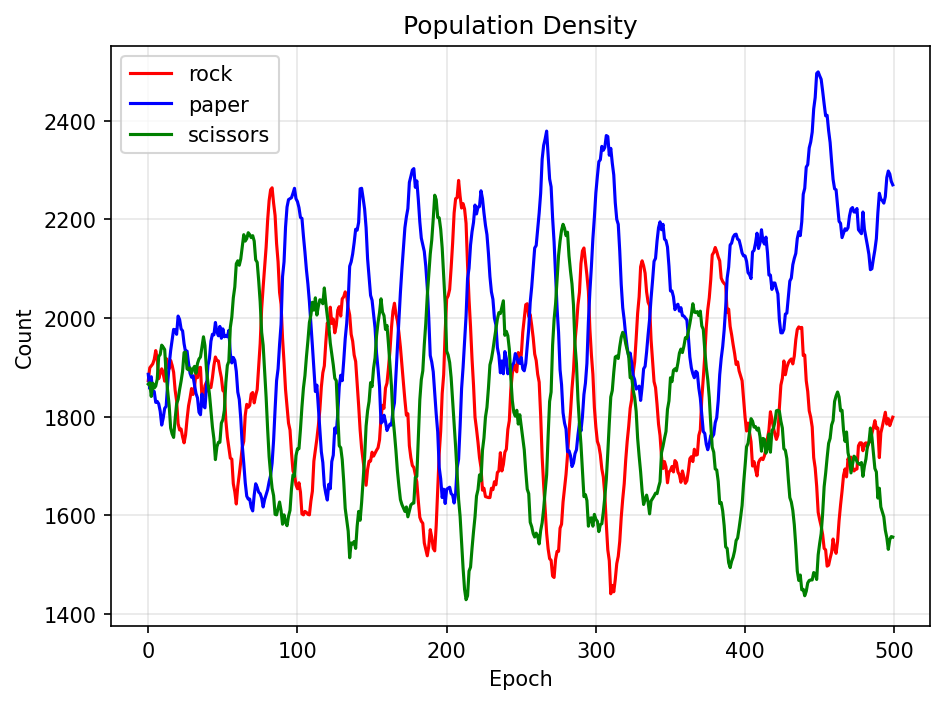

In [34]:
plot_densities(data)

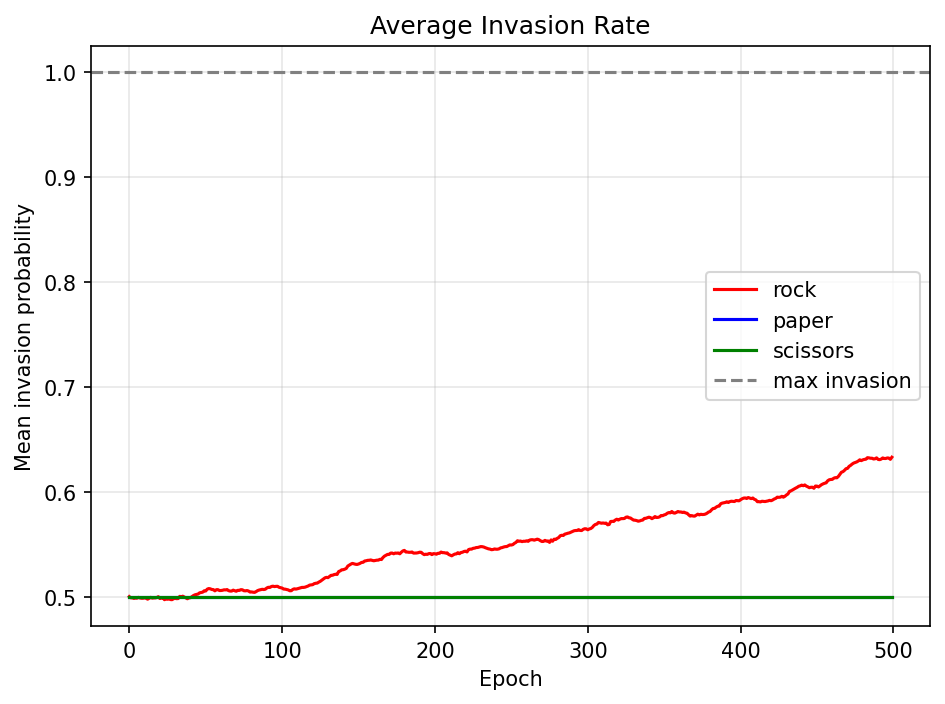

In [35]:
plot_average_invasions(data)

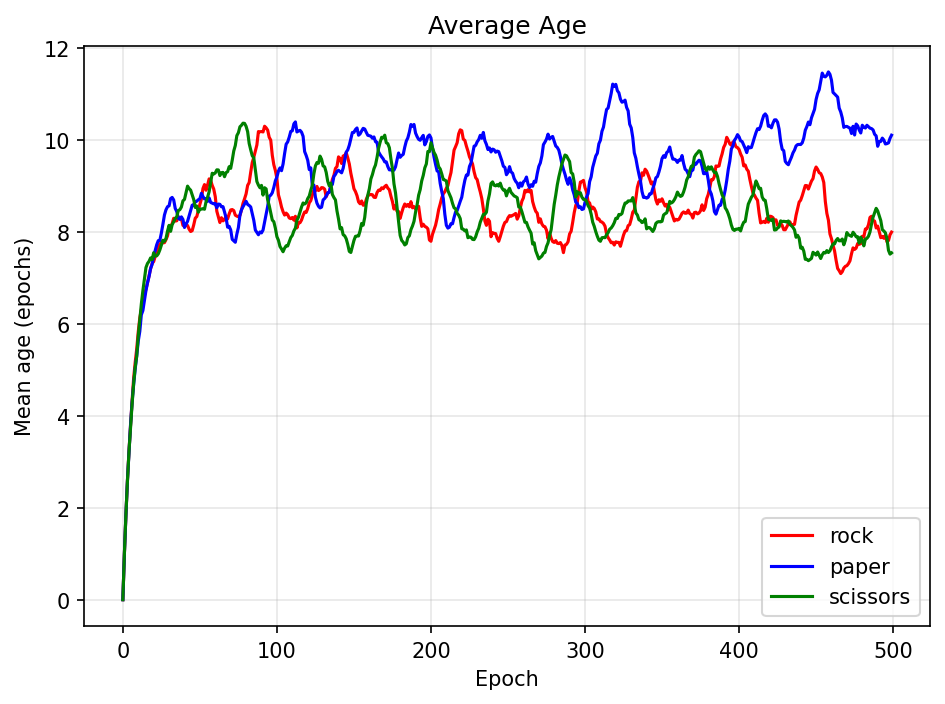

In [36]:
plot_average_age(data)

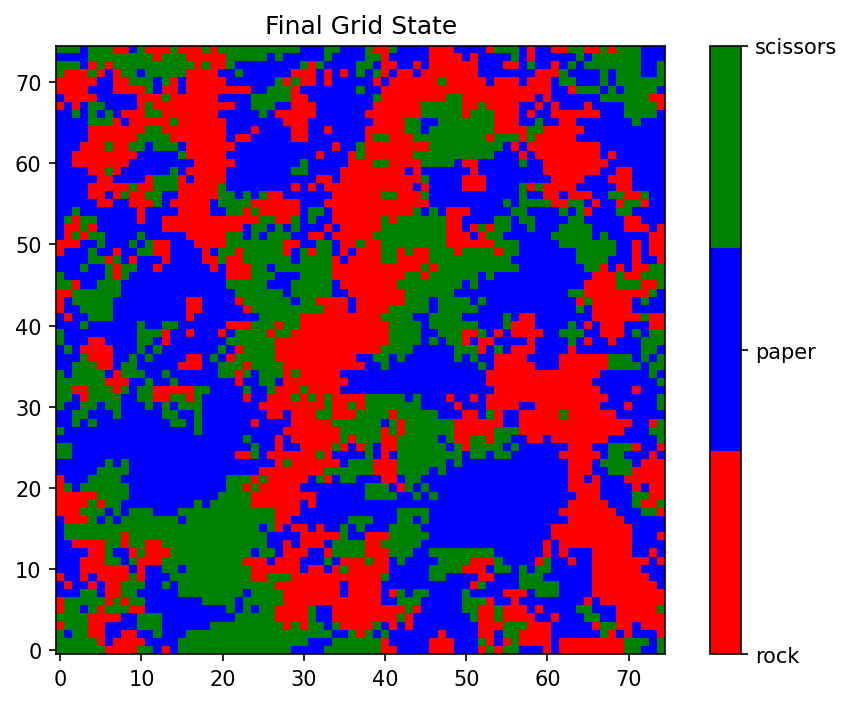

In [37]:
visualize_grid(model)

In [38]:
policies = {
    "rock": evo.Genetic(sigma=sigma, radius=radius),
    "paper": evo.Genetic(sigma=sigma, radius=radius),
    "scissors": evo.Genetic(sigma=sigma, radius=radius),
}

model = RPSModel(
    dim=dim,
    policies=policies,
    initial_invasions=[0.5, 0.5, 0.5],
    rng=42,
)

model.run_for(epochs, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

100%|██████████| 500/500 [22:41<00:00,  2.72s/it]


,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,1873,1886,1866,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000
1,1903,1877,1845,0.501225,0.499334,0.500985,1.000000,1.000000,1.000000
2,1898,1892,1835,0.501971,0.499408,0.500393,1.860379,1.852008,1.856676
3,1880,1880,1865,0.501752,0.500598,0.500823,2.615957,2.594149,2.588204
4,1867,1866,1892,0.501154,0.501026,0.501813,3.262453,3.211683,3.192918
...,...,...,...,...,...,...,...,...,...
495,1691,1823,2111,0.609385,0.633452,0.611790,6.971614,7.723533,7.995263
496,1725,1812,2088,0.609916,0.633710,0.611970,6.897971,7.705850,8.049330
497,1788,1764,2073,0.609299,0.634555,0.612464,6.846756,7.816893,8.023155
498,1815,1745,2065,0.610815,0.636129,0.613354,6.801653,7.755874,8.096852


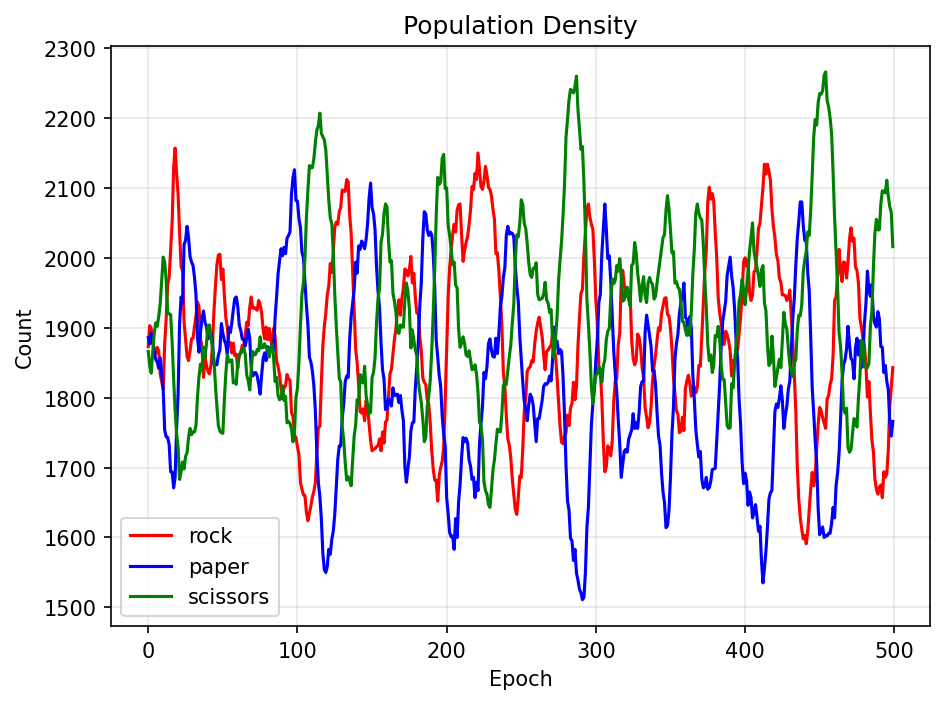

In [39]:
plot_densities(data)

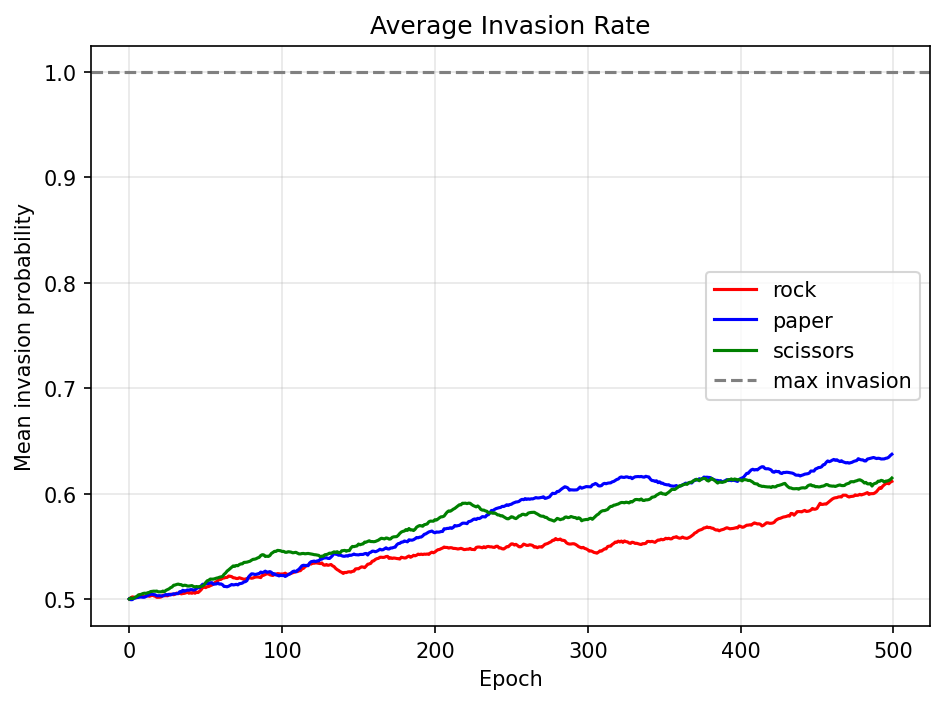

In [40]:
plot_average_invasions(data)

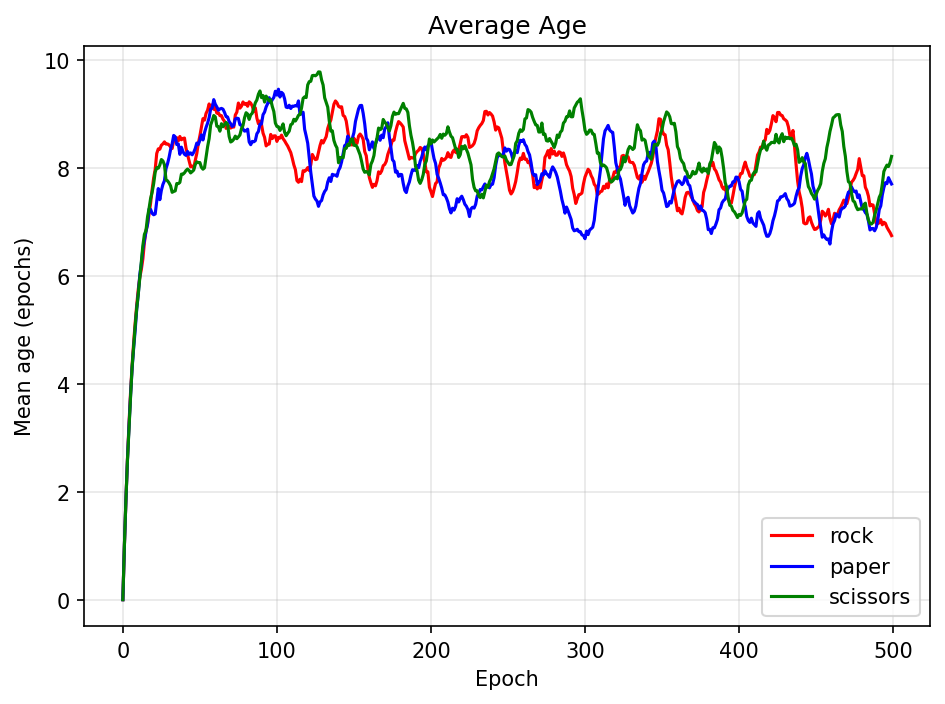

In [41]:
plot_average_age(data)

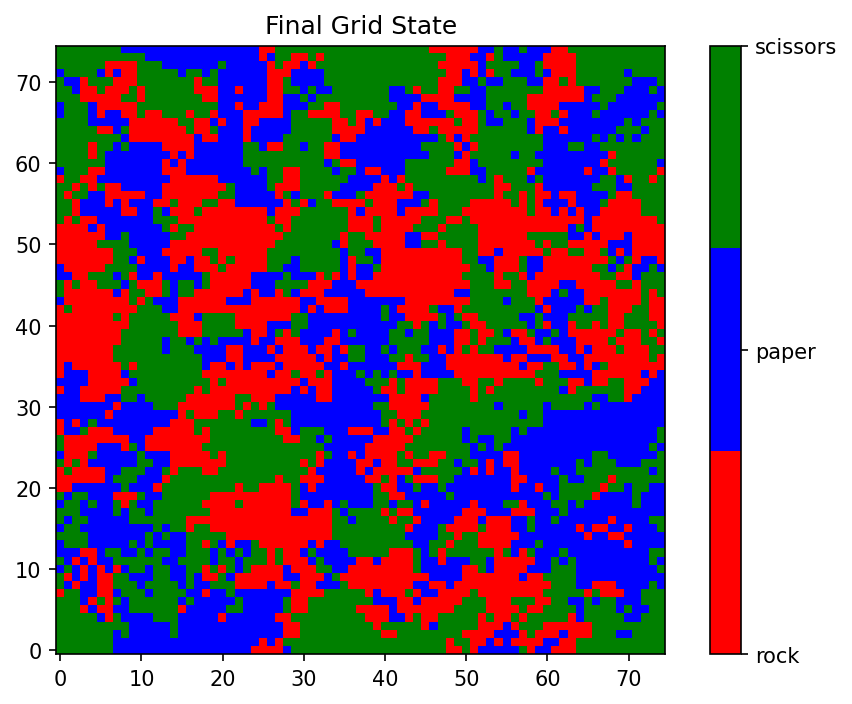

In [42]:
visualize_grid(model)